# Multi-arm geo lift with PyMC: up, down, and control

A geo lift test can assign two active arms: increase media spend in some geos (up), decrease it in others (down), and leave control geos unchanged. The up and down arms probe the revenue response on opposite sides of business-as-usual spend. We estimate each treated geo's signed revenue effect relative to its own business-as-usual path, rather than subtracting the down arm from the up arm.

The workflow has four stages:

1. Plan the geo assignments, spend changes, and test duration. We assume those decisions have already been made; experimental design is outside this example.
2. Run the intervention and record delivered spend and revenue. Here we simulate that real-world step, so the no-intervention outcomes and true effects in this simulated world are known.
3. Fit a synthetic-control counterfactual from the unchanged geos, inspect its fit, and estimate the up and down effects with `UpDownGeoLift`.
4. Export geo-level lift observations for a geo-varying PyMC-Marketing MMM. A future PyMC-Marketing documentation page will show the calibration step.

The key assumptions are that the intervention does not spill over into control geos, the pre-intervention relationship between treated and control geos remains useful afterward, and no other change at the intervention date differs systematically by arm. Assignment labels record the intended direction; delivered spend defines the intervention actually analyzed.

## Simulate assignment and delivered spend

The simulated panel is weekly and has two media channels, `search` and `display`. This experiment changes `search` while `display` remains unchanged. Geos have different sizes, represented by distinct baseline search spend and revenue levels. The unchanged controls span the treated geos on both measures, so a nonnegative weighted average of controls can interpolate each treated geo's business-as-usual revenue level. Up and down geos also have different saturation parameters, so their true effects vary by geo. Planned spend changes offset in total, while delivered changes are smaller because delivery is 90% of plan.

In [1]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter
from myst_nb import glue

import causalpy as cp
from causalpy.data.simulate_data import generate_up_down_geolift_data

FIG_WIDTH = 8
FIG_HEIGHT = 4.5
COLOR_UP = "#007F5F"
COLOR_DOWN = "#C74428"
COLOR_CONTROL = "#355C9B"
GEO_COLORS = {
    "up_1": "#007F5F",
    "up_2": "#4A7C00",
    "down_1": "#D14900",
    "down_2": "#B51F4E",
    "control_1": "#2155A3",
    "control_2": "#7952A2",
    "control_3": "#815A38",
    "control_4": "#007D9A",
    "control_5": "#424B5A",
}

simulated = generate_up_down_geolift_data(seed=415, n_pre=32, n_post=8, n_control=5)
simulated.arms

{'up': ['up_1', 'up_2'],
 'down': ['down_1', 'down_2'],
 'control': ['control_1', 'control_2', 'control_3', 'control_4', 'control_5']}

The `arms` mapping records assignment. The `spend_planned` and `spend_realized` panels record intended and delivered spend; `spend_baseline` is the business-as-usual path. The simulator also exposes the no-intervention revenue and treatment effects, which would be unobserved in a real experiment.

**Caption:** Weekly search spend (top) and revenue (bottom) for every geo, in USD per week. Each geo keeps the same color in both panels; dashed lines show the simulated business-as-usual path for treated geos. The shaded revenue range runs from the lowest to the highest control geo each week. The black vertical line marks the first intervention week.

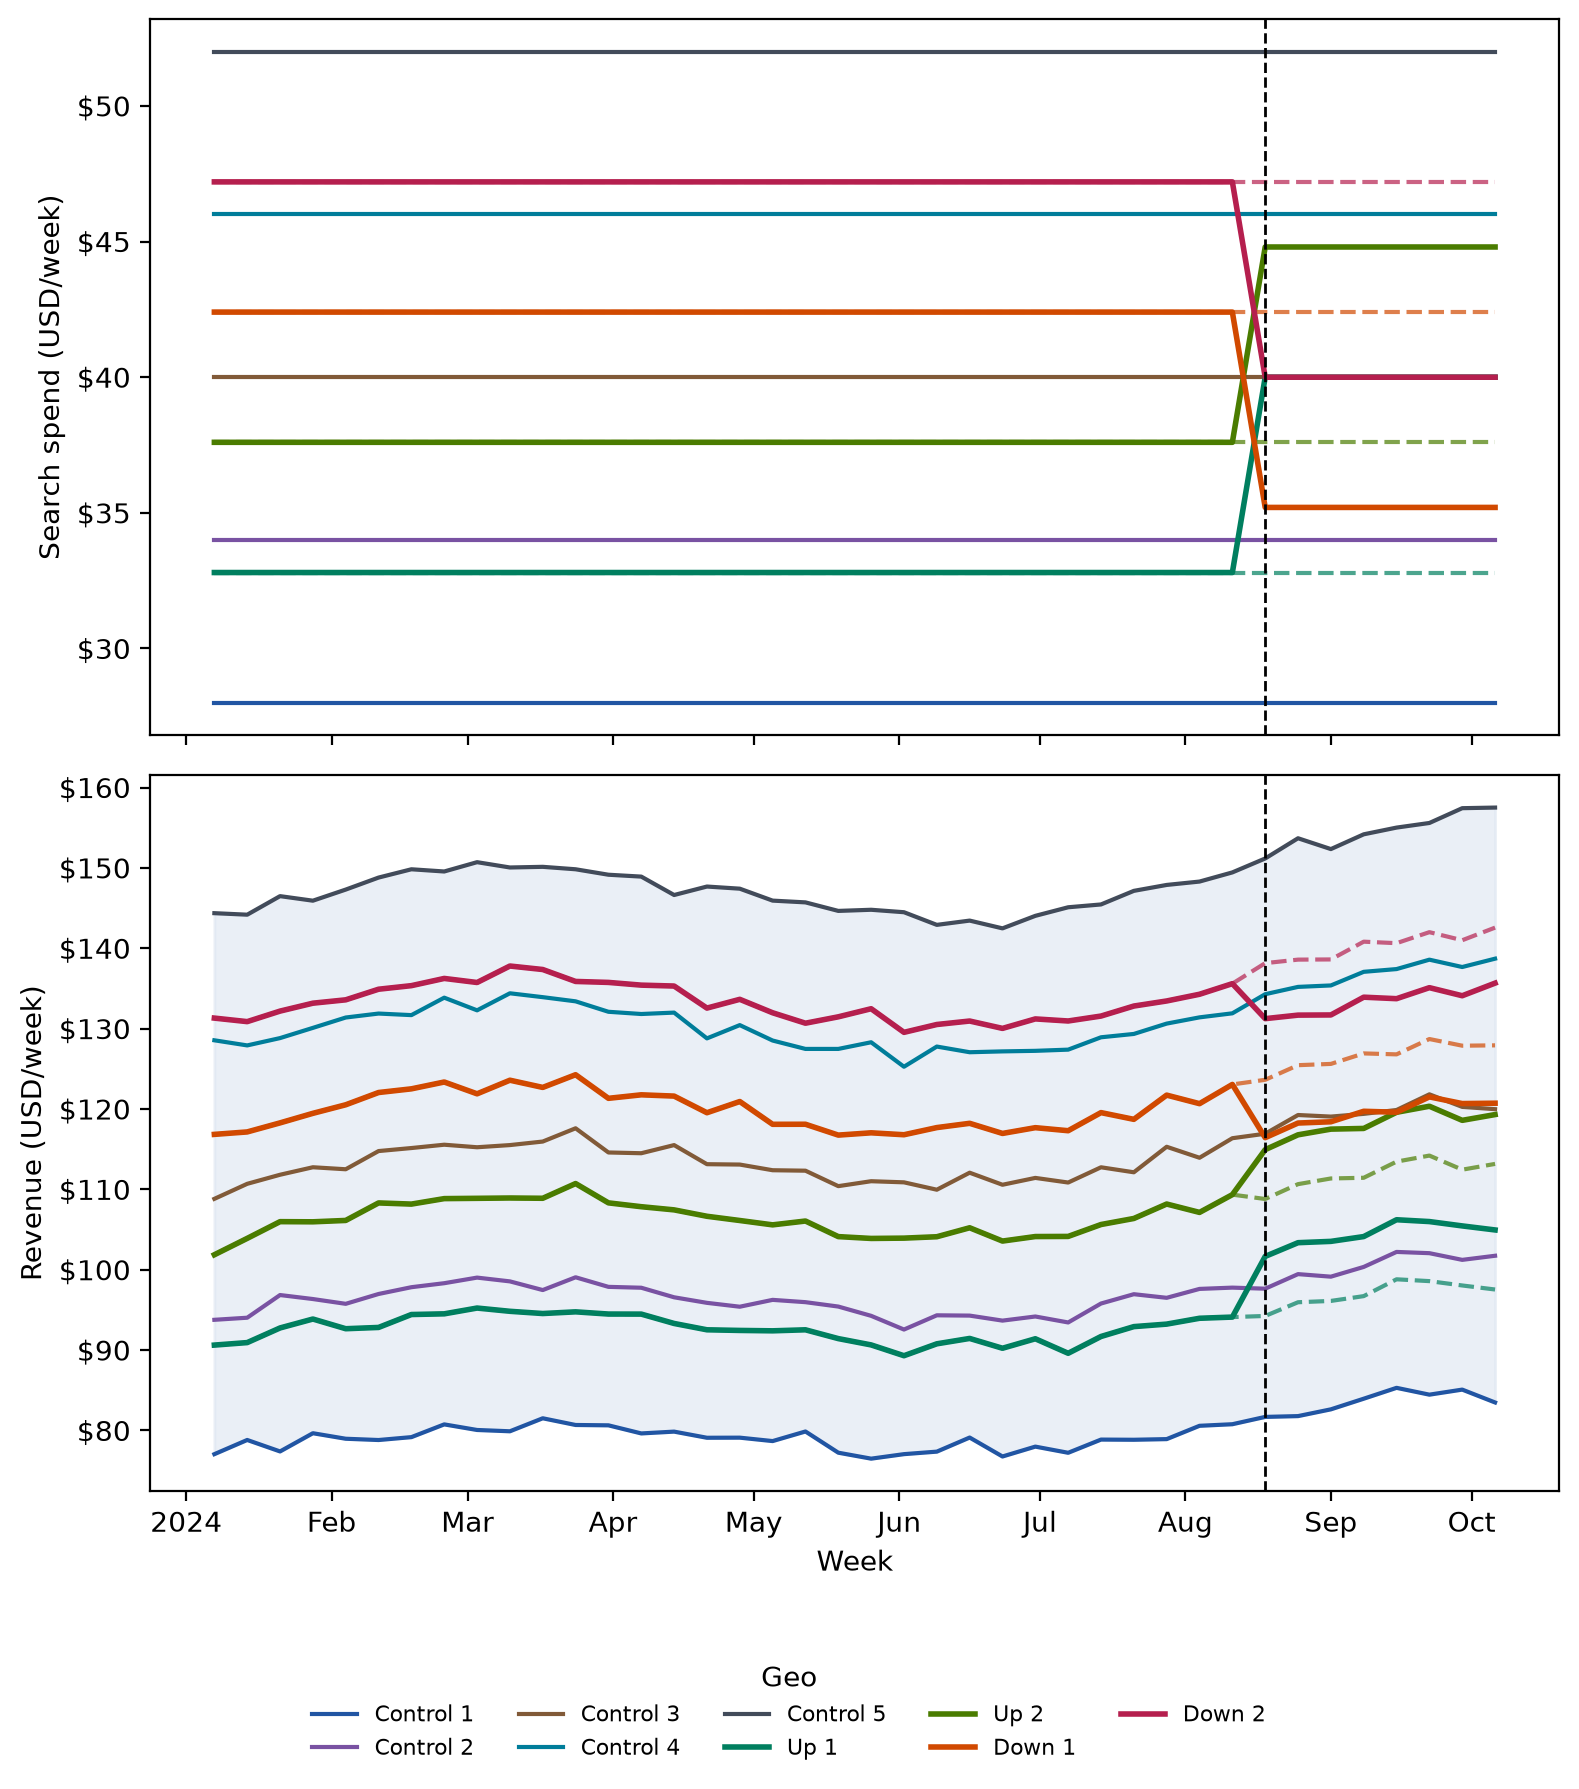

In [2]:
baseline_search = simulated.spend_baseline.xs("search", axis=1, level="channel")
realized_search = simulated.spend_realized.xs("search", axis=1, level="channel")
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(FIG_WIDTH, FIG_HEIGHT * 2))
controls = simulated.arms["control"]
treated = simulated.arms["up"] + simulated.arms["down"]
axes[1].fill_between(
    simulated.revenue.index,
    simulated.revenue[controls].min(axis=1),
    simulated.revenue[controls].max(axis=1),
    color="#DDE5F1",
    alpha=0.6,
    zorder=0,
)
for arm in ("control", "up", "down"):
    for geo in simulated.arms[arm]:
        color = GEO_COLORS[geo]
        axes[0].plot(
            realized_search.index,
            realized_search[geo],
            color=color,
            linewidth=2 if arm != "control" else 1.5,
            label=geo.replace("_", " ").title(),
        )
        axes[1].plot(
            simulated.revenue.index,
            simulated.revenue[geo],
            color=color,
            linewidth=2 if arm != "control" else 1.5,
        )
        if arm != "control":
            axes[0].plot(
                baseline_search.index,
                baseline_search[geo],
                color=color,
                linestyle="--",
                alpha=0.7,
            )
            axes[1].plot(
                simulated.no_intervention.index,
                simulated.no_intervention[geo],
                color=color,
                linestyle="--",
                alpha=0.7,
            )
for ax in axes:
    ax.axvline(simulated.treatment_time, color="black", linestyle="--", linewidth=1)
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[0].set_ylabel("Search spend (USD/week)")
axes[1].set_ylabel("Revenue (USD/week)")
axes[1].set_xlabel("Week")
fig.legend(
    *axes[0].get_legend_handles_labels(),
    title="Geo",
    ncol=5,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    fontsize=8,
)
locator = mdates.AutoDateLocator()
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

Control geos have both lower and higher baseline spend and revenue than the treated geos. Each solid line is one geo, so the different levels and the up and down spend changes are visible without averaging away geo size. Before the intervention, delivered and business-as-usual paths coincide. Afterward, the dashed revenue paths show the known no-intervention outcomes in this simulated world; the estimator does not observe them.

## Synthetic control and the up/down extension

{term}`Synthetic control` builds a weighted combination of unchanged control geos (the donor pool) to track each treated geo before the intervention. After the intervention, the same weights applied to the controls estimate what the treated geo's revenue would have been without its spend change. Observed revenue minus this counterfactual is the signed effect. With nonnegative weights that sum to one, the synthetic geo interpolates within the donor pool rather than extrapolating beyond it. We deliberately simulate smaller and larger controls to make that comparison plausible, then inspect the actual pre-intervention fit. A close fit supports the comparison, but it cannot by itself rule out spillovers or a concurrent geo-specific shock. For a single-treated-unit introduction, see {doc}`synthetic-control-pymc`.

`UpDownGeoLift` uses the same `SyntheticControl` counterfactual machinery. It asks for explicit, disjoint `up`, `down`, and `control` assignments, uses only control geos as donors, and fits the treated geos together so their posterior draws stay aligned. It retains each treated geo's weekly effect and summarizes the up and down arms separately within each draw. Its inherited three-panel plot lets us inspect the observed and synthetic trajectories, weekly impact, and cumulative impact for any treated geo.

## Fit the counterfactual

For each treated geo and post-intervention week, the estimand is observed revenue under delivered spend minus revenue under its business-as-usual spend path. `UpDownGeoLift` estimates the second term from unchanged controls; down geos are treated units, never donors. We use Bayesian nonnegative weights that sum to one and retain the aligned `chain` and `draw` coordinates across geos.

In [3]:
model = cp.pymc_models.SoftmaxWeightedSumFitter(
    sample_kwargs={
        "draws": 500,
        "tune": 500,
        "chains": 2,
        "cores": 2,
        "target_accept": 0.95,
        "random_seed": 415,
        "progressbar": False,
    }
)
result = cp.UpDownGeoLift(
    simulated.revenue,
    treatment_time=simulated.treatment_time,
    arms=simulated.arms,
    model=model,
).fit()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta_raw, y_hat_sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [beta_raw, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


## Inspect the counterfactual fit

Use the inherited `plot()` method for every treated geo. Each three-panel diagnostic compares observed revenue with the fitted pre-intervention trajectory and post-intervention counterfactual, then shows weekly and cumulative impact. Select each tab to check whether the controls reproduce that geo before the intervention and whether the uncertainty bands support the effect estimate. A good pre-intervention fit does not establish the no-spillover or no-concurrent-shock assumptions on its own.

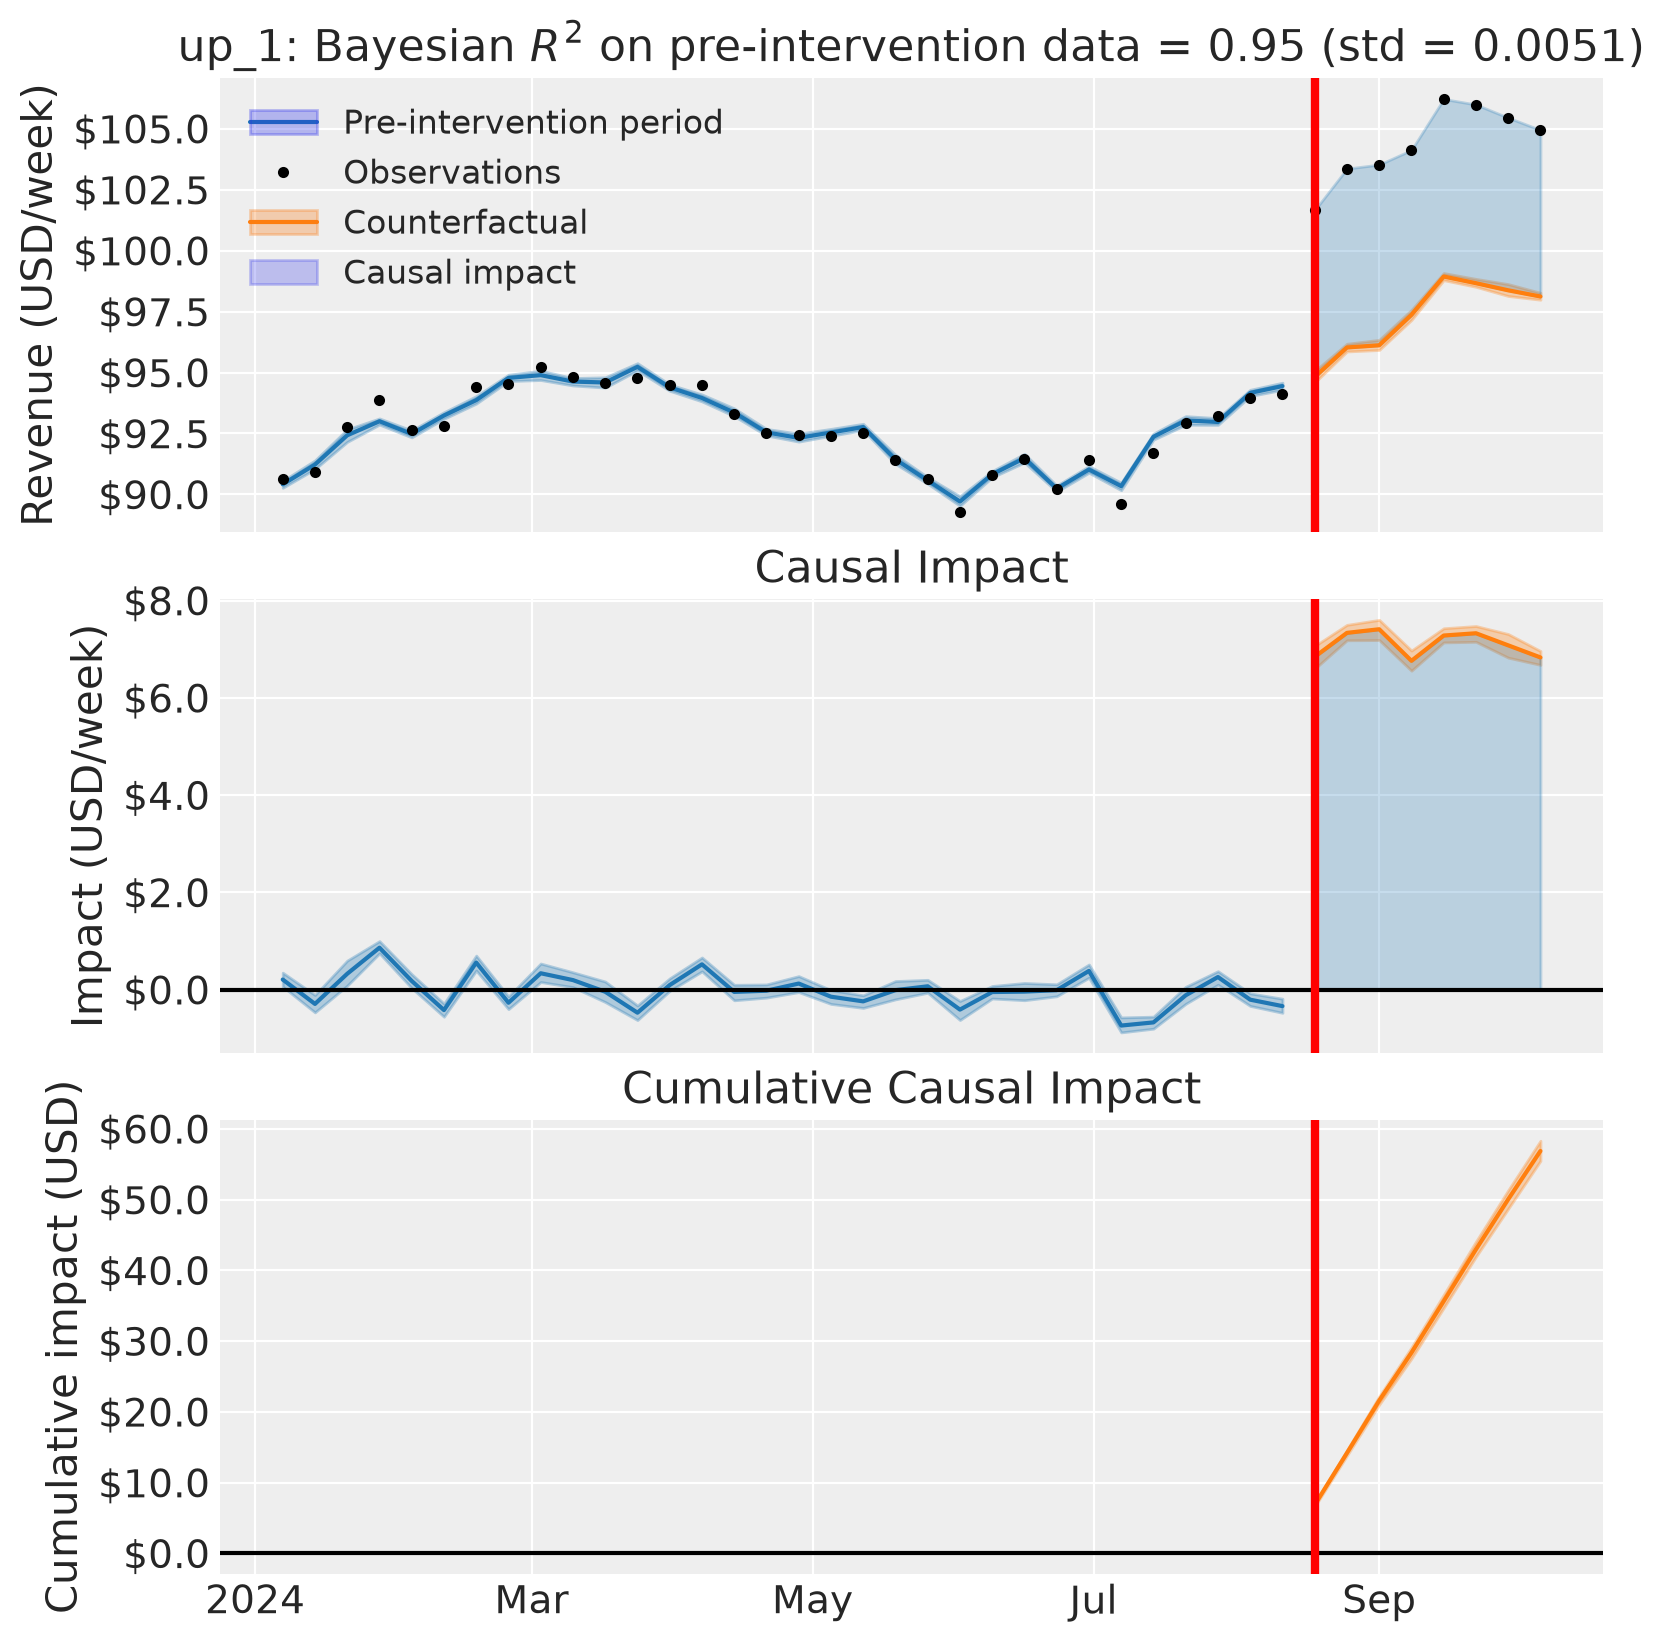

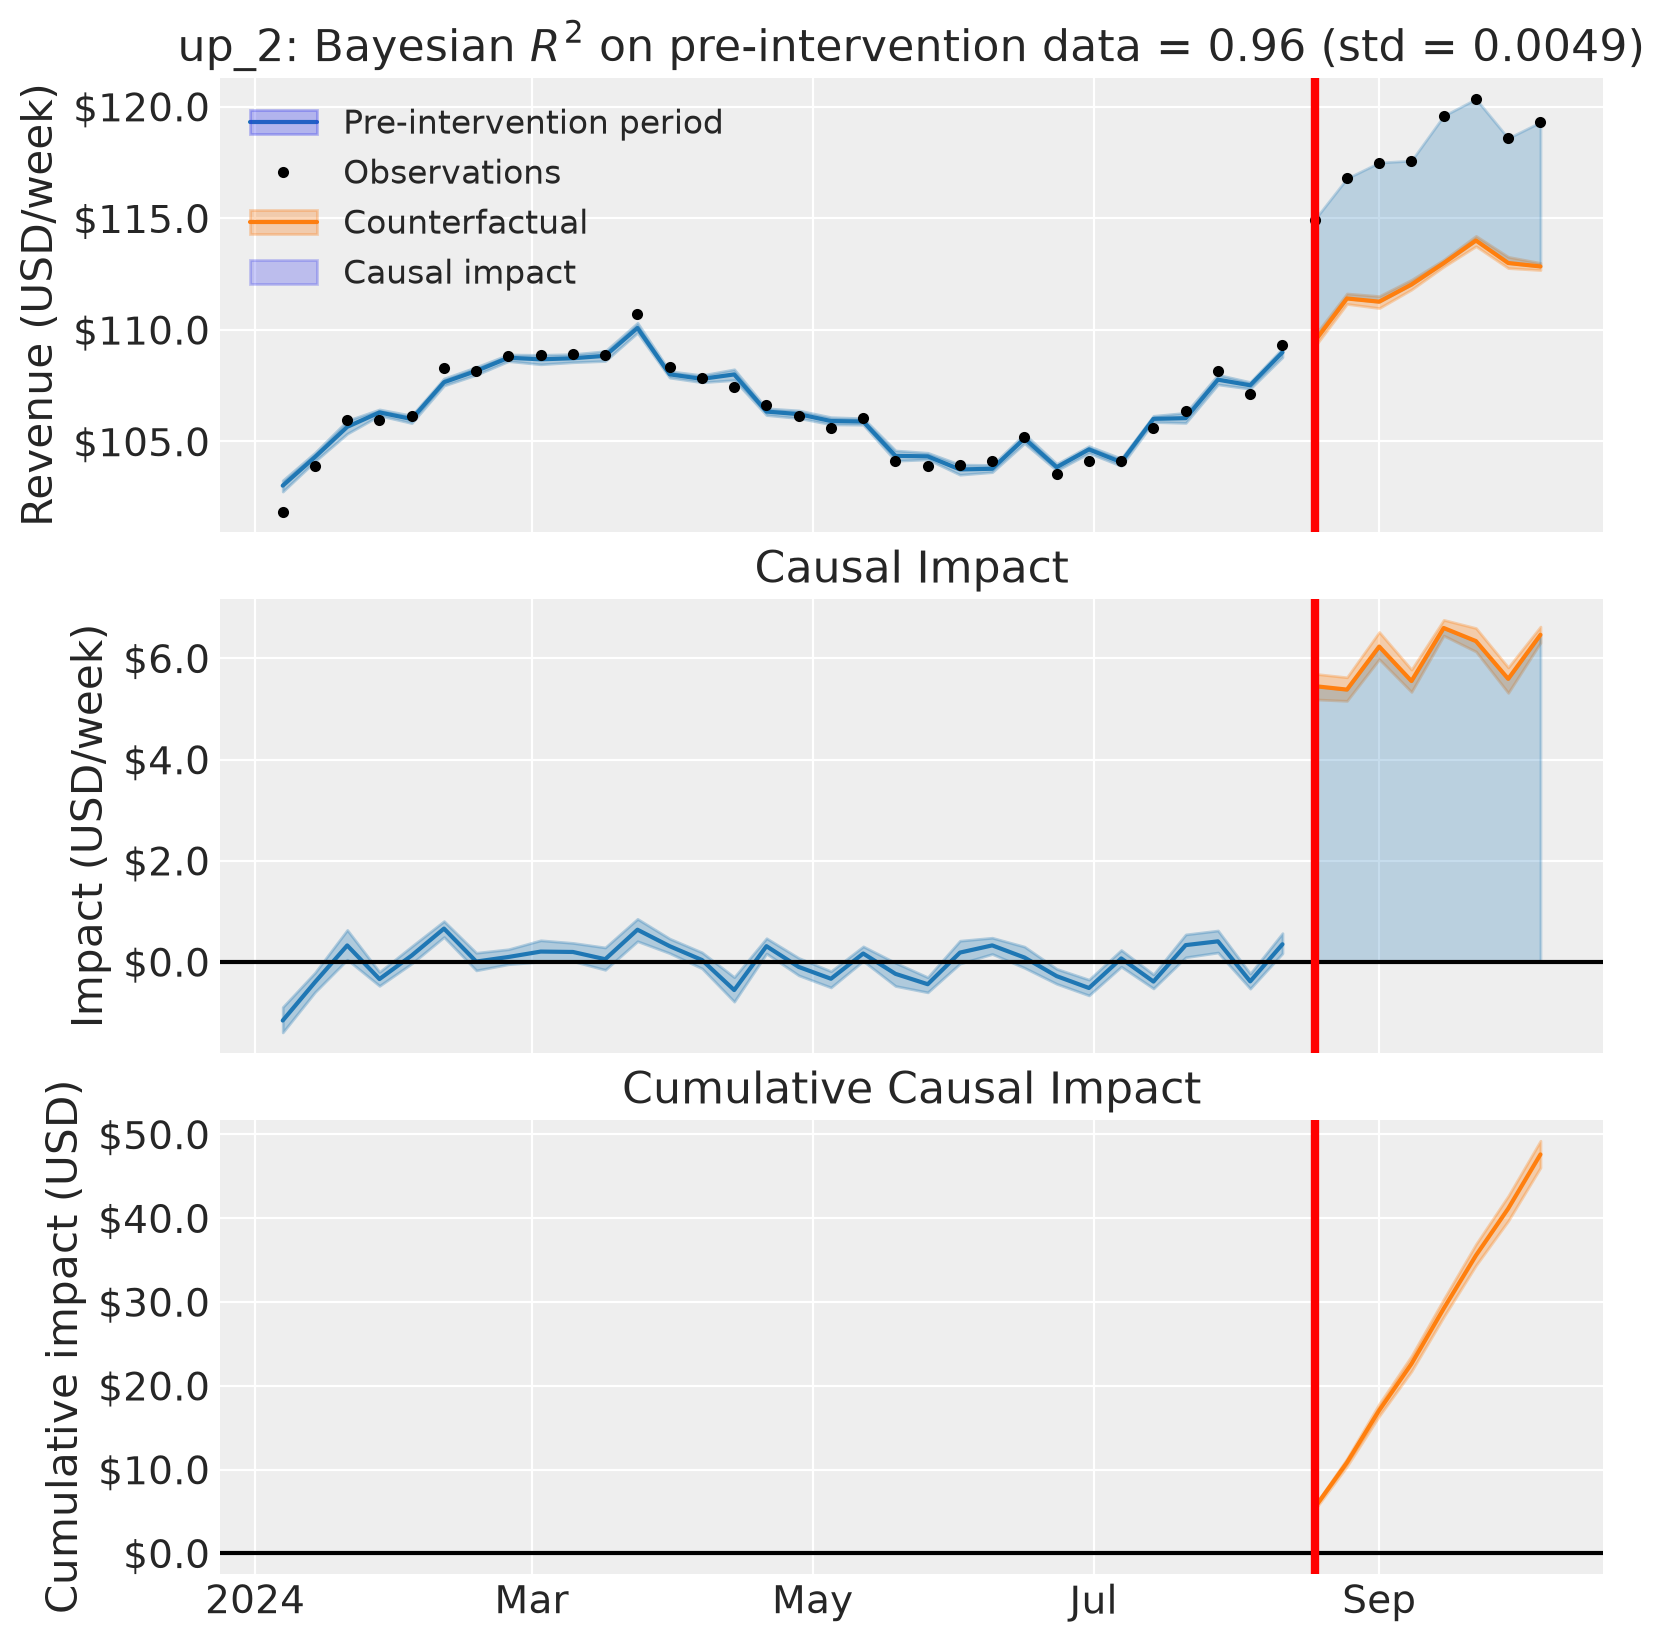

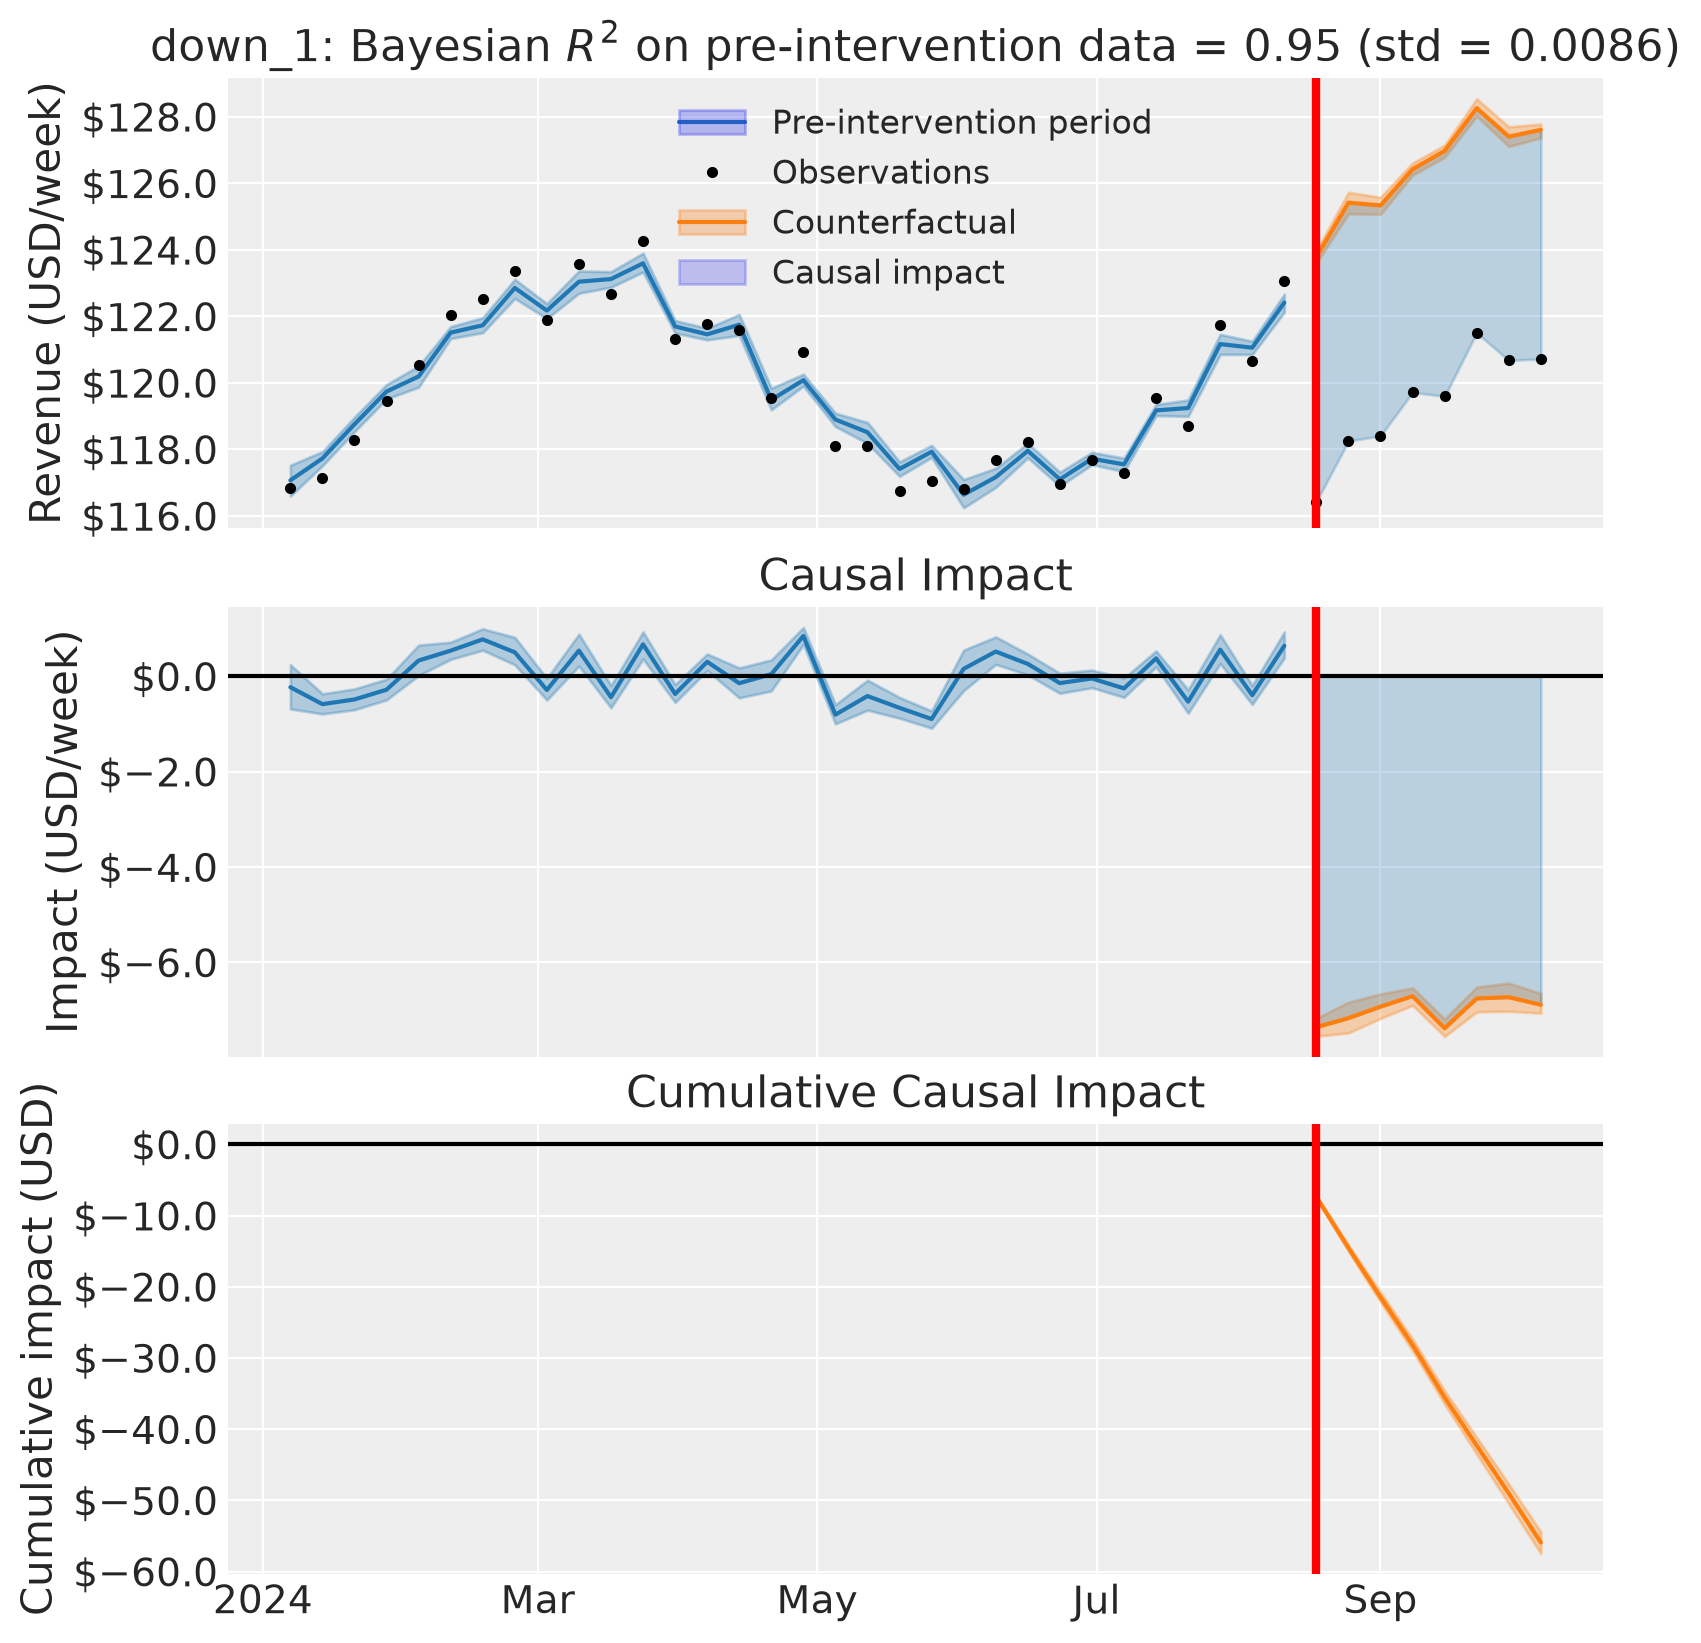

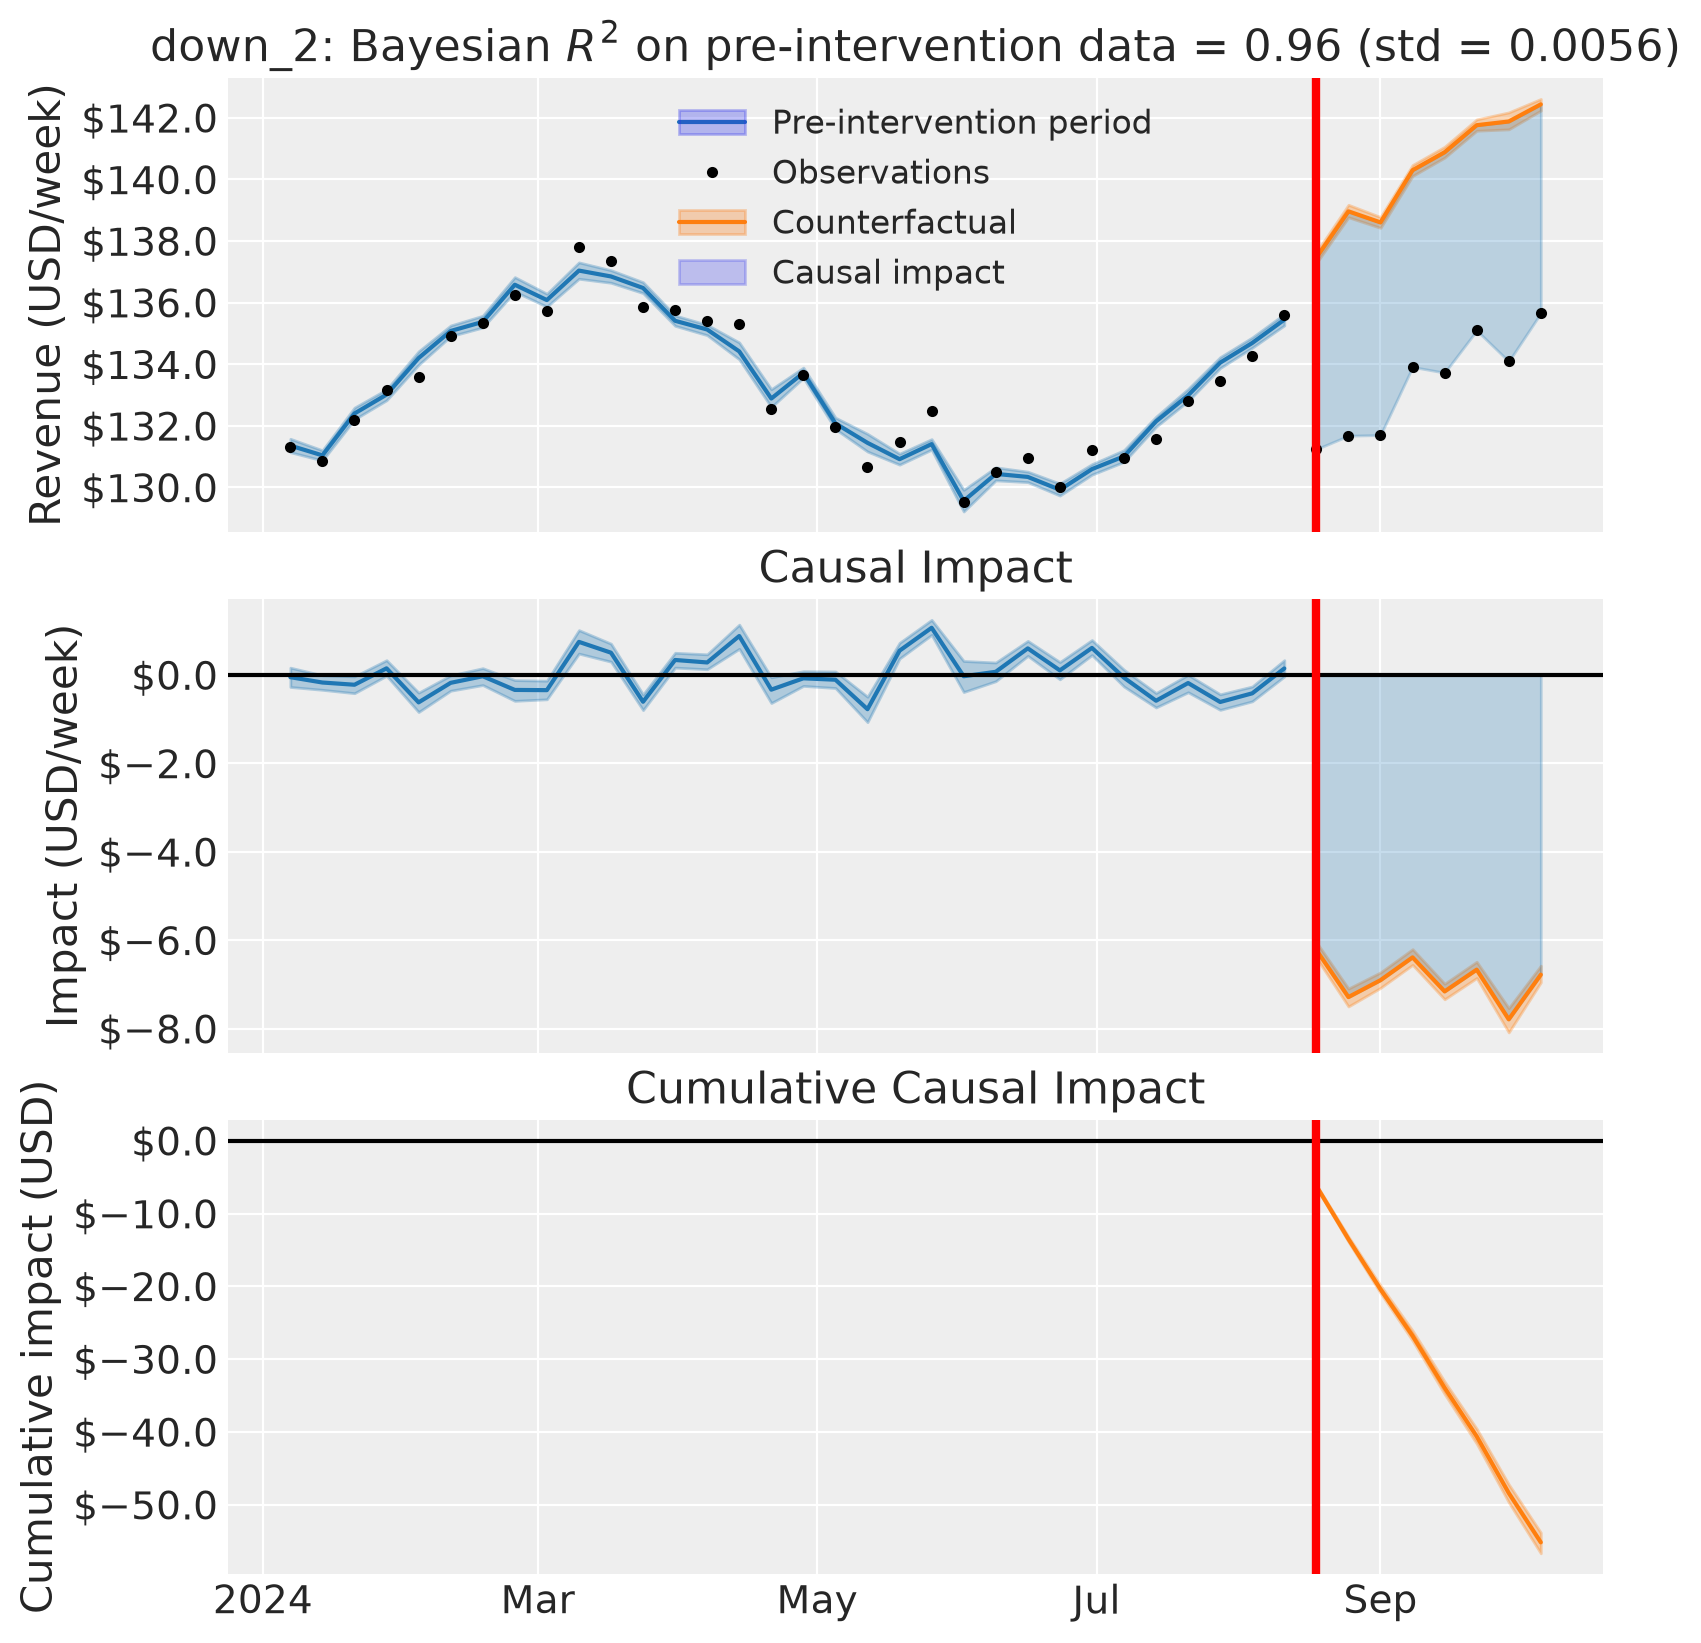

In [4]:
for arm in ("up", "down"):
    for geo in simulated.arms[arm]:
        fig, axes = result.plot(
            treated_unit=geo, figsize=(FIG_WIDTH, FIG_HEIGHT * 1.8), show=False
        )
        glue(f"geo-lift-{geo}", fig, display=True)
        plt.close(fig)

::::{tab-set}
:::{tab-item} Up 1
```{glue:figure} geo-lift-up_1
:alt: Three-panel synthetic-control diagnostics for up geo one.

Up arm, geo `up_1`: revenue and weekly impact are in USD per week; cumulative impact is in USD. Bands are 94% posterior intervals.
```
:::
:::{tab-item} Up 2
```{glue:figure} geo-lift-up_2
:alt: Three-panel synthetic-control diagnostics for up geo two.

Up arm, geo `up_2`: revenue and weekly impact are in USD per week; cumulative impact is in USD. Bands are 94% posterior intervals.
```
:::
:::{tab-item} Down 1
```{glue:figure} geo-lift-down_1
:alt: Three-panel synthetic-control diagnostics for down geo one.

Down arm, geo `down_1`: revenue and weekly impact are in USD per week; cumulative impact is in USD. Bands are 94% posterior intervals.
```
:::
:::{tab-item} Down 2
```{glue:figure} geo-lift-down_2
:alt: Three-panel synthetic-control diagnostics for down geo two.

Down arm, geo `down_2`: revenue and weekly impact are in USD per week; cumulative impact is in USD. Bands are 94% posterior intervals.
```
:::
::::

Inspect all four tabs before using their lift estimates. The upper panel tests how well the controls reproduce each geo before the intervention; the middle and lower panels show whether weekly and cumulative impacts are consistent with the assigned spend direction. These visual diagnostics cannot prove the no-spillover or no-concurrent-shock assumptions, which still require design knowledge.

## Summarize signed geo and arm effects

The table keeps every treated geo and the two active arms separate. Arm means are computed from the same posterior draw across geos, so the uncertainty reflects their joint fit.

In [5]:
result.arm_effect_table()

,level,geo,arm,mean,sd,lower_94,upper_94,window_start,window_end,n_periods,aggregate
0,geo,up_1,up,7.108838,0.097239,6.914591,7.280235,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
1,geo,up_2,up,5.951735,0.107402,5.757519,6.157976,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
2,geo,down_1,down,-6.987615,0.101584,-7.180463,-6.794666,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
3,geo,down_2,down,-6.896968,0.095172,-7.078783,-6.718786,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
4,arm,NaN,up,6.530287,0.073528,6.391523,6.666642,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
5,arm,NaN,down,-6.942291,0.071275,-7.074529,-6.810725,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean


The table reports a signed mean effect per week for each treated geo and a separate mean for each arm. The 94% intervals summarize posterior draws after averaging geos within each draw, preserving the dependence among geo estimates. A cumulative effect is available with `aggregate="sum"`. Because the donor weights are nonnegative and sum to one, check the {term}`Convex hull condition` alongside the fit plots before treating the intervals as complete uncertainty about the counterfactual. The broad donor range in our simulation helps with interpolation, but it does not replace checking the fitted trajectories.

:::{note}
**Recommended refutation checks (TODO).** Before using the lift estimates for MMM calibration, consider placebo-in-time checks that assign an intervention date in the pre-period and placebo-in-space checks that treat an unchanged geo as if it had received the intervention. Large apparent effects in either setting would warrant investigating donor fit, concurrent changes, and spillovers. We plan to add worked examples of these optional but recommended checks; they do not by themselves prove the causal assumptions.
:::

## Check recovery against known simulated effects

Because we simulated the data, we know each geo's no-intervention potential outcome and the effect of its delivered spend change. This parameter-recovery check compares the true mean weekly effect in this simulated world with the posterior estimate over the same eight-week window.

**Caption:** Posterior mean weekly revenue effect and 94% equal-tailed interval by treated geo; open circles mark the known simulation truth. Colors identify assignment arms.

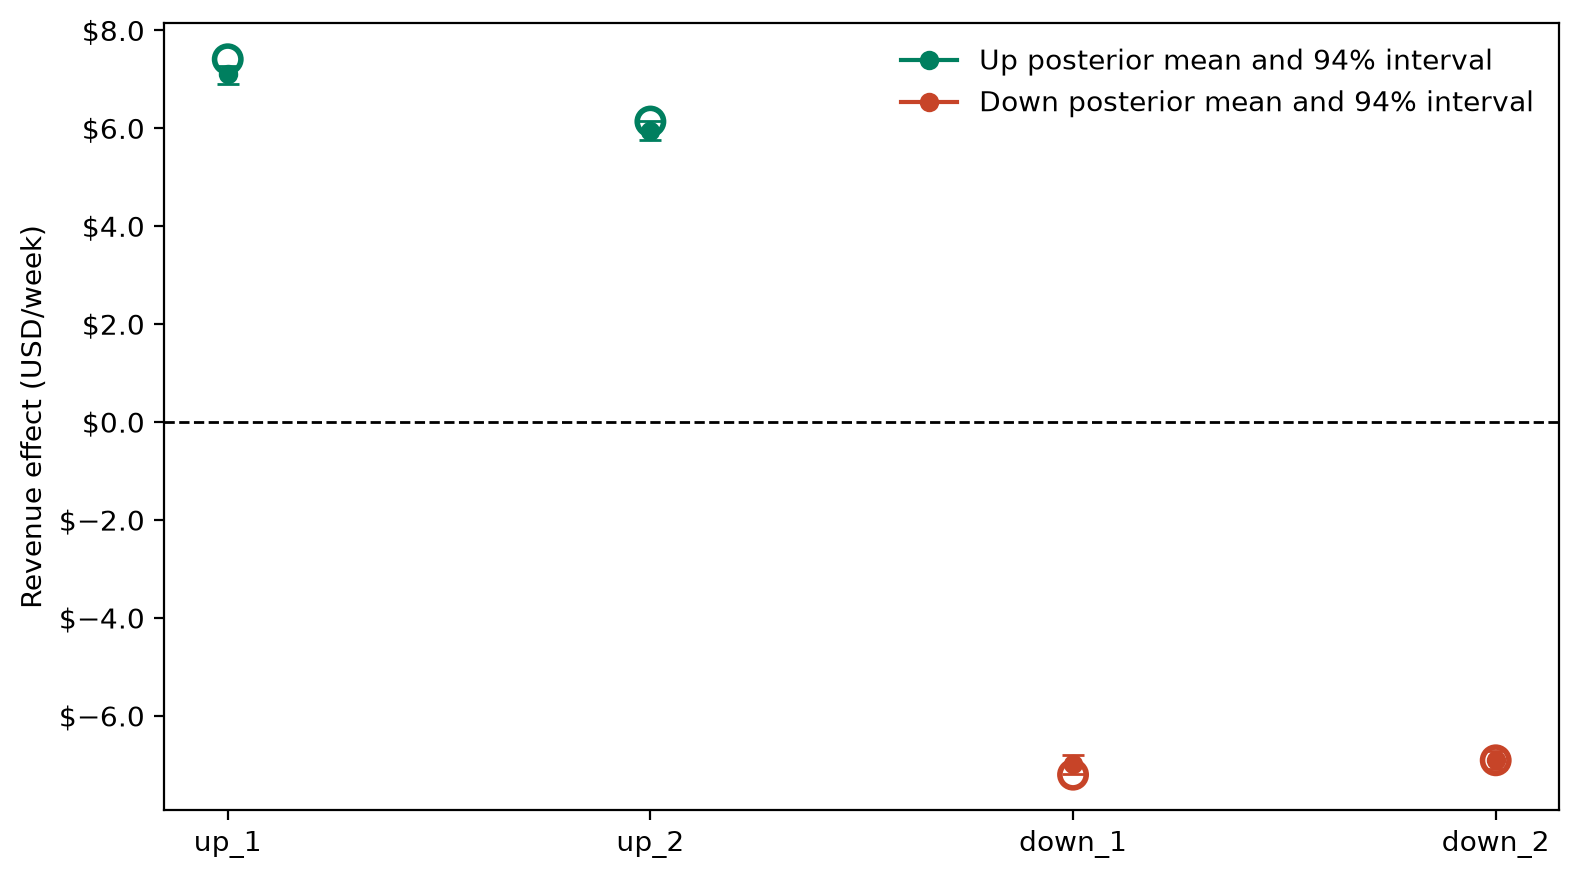

In [6]:
table = result.arm_effect_table()
geo_table = table.loc[table["level"] == "geo"].set_index("geo")
truth = simulated.effects.loc[simulated.treatment_time :].mean()
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
for position, geo in enumerate(result.treated_units):
    row = geo_table.loc[geo]
    color = COLOR_UP if row["arm"] == "up" else COLOR_DOWN
    ax.errorbar(
        position,
        row["mean"],
        yerr=[[row["mean"] - row["lower_94"]], [row["upper_94"] - row["mean"]]],
        fmt="o",
        color=color,
        capsize=4,
        linewidth=2,
        zorder=3,
    )
    ax.scatter(
        position,
        truth[geo],
        facecolors="none",
        edgecolors=color,
        s=90,
        linewidths=2,
        zorder=4,
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(result.treated_units)), result.treated_units)
ax.set_ylabel("Revenue effect (USD/week)")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.1f}"))
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=COLOR_UP,
            marker="o",
            label="Up posterior mean and 94% interval",
        ),
        Line2D(
            [0],
            [0],
            color=COLOR_DOWN,
            marker="o",
            label="Down posterior mean and 94% interval",
        ),
    ],
    frameon=False,
    loc="best",
)
fig.tight_layout()
plt.show()

The estimated effects have the correct signs, but the known simulated effect falls outside some 94% intervals. This is a limit of the recovery in this run, not evidence that the true effect is unknown here: the simulator gives us that truth. The donor model's posterior interval does not include every source of counterfactual error in the simulated panel. Inspect pre-intervention fit and posterior diagnostics before using a row for calibration.

## Build scalar MMM calibration rows

For the selected complete weekly window, `x` is mean business-as-usual search spend per week, `delta_x` is mean realized minus business-as-usual search spend per week, and `delta_y` is mean signed revenue effect per week. `sigma` is the posterior standard deviation of that mean effect. The revenue and both spend panels carry `attrs["unit"] = "USD/week"`, which the exporter checks against the declared units. Both spend panels must contain every selected outcome week. Baseline spend and delivered change must remain stable across the window; otherwise a nonlinear saturation response at mean spend is not the mean response to a changing spend path. The exported rows retain arm, `window_start`, `window_end`, period count, and unit metadata. The window boundaries are timestamps for the lift observation analyzed here. [PyMC-Marketing's current lift-test method](https://www.pymc-marketing.io/en/latest/api/generated/classmethods/pymc_marketing.mmm.mmm.MMM.add_lift_test_measurements.html) does not consume start or end dates. It can use a separate single `date` coordinate for a time-varying media model, but the window boundaries here remain metadata alongside the estimate and could support future calibration features. PyMC-Marketing uses the scalar likelihood columns plus `geo` when geo is an MMM dimension.

In [7]:
lift_rows = result.to_mmm_lift(
    spend_baseline=simulated.spend_baseline,
    spend_realized=simulated.spend_realized,
    channel=simulated.tested_channel,
    spend_unit="USD/week",
    outcome_unit="USD/week",
    start=simulated.treatment_time,
    end=simulated.revenue.index[-1],
)
lift_rows[
    [
        "channel",
        "geo",
        "arm",
        "x",
        "delta_x",
        "delta_y",
        "sigma",
        "window_start",
        "window_end",
        "n_periods",
    ]
]

,channel,geo,arm,x,delta_x,delta_y,sigma,window_start,window_end,n_periods
0,search,up_1,up,32.8,7.2,7.108838,0.097239,2024-08-18,2024-10-06,8
1,search,up_2,up,37.6,7.2,5.951735,0.107402,2024-08-18,2024-10-06,8
2,search,down_1,down,42.4,-7.2,-6.987615,0.101584,2024-08-18,2024-10-06,8
3,search,down_2,down,47.2,-7.2,-6.896968,0.095172,2024-08-18,2024-10-06,8


The rows are marginal summaries for a scalar lift likelihood. The joint posterior remains available as `result.impact_draws` or through `result.aggregate_draws()`. A downstream model that needs cross-geo covariance should use those draws instead of treating the rows as independent. The simple simulator has no carryover; if an experiment has delayed effects, verify that the chosen stable response window and spend definition match the MMM's adstock convention before exporting.

:::{note}
**TODO: PyMC-Marketing calibration walkthrough.** Link here to a PyMC-Marketing documentation page showing how to pass these geo-level lift rows into a geo-varying MMM when that page is available. This CausalPy example stops at the export contract.
:::

## Summary

- Keep up and down effects signed and summarize the two active arms separately.
- Choose unchanged controls that span treated baseline outcomes, inspect the counterfactual fit for every treated geo, and consider placebo refutation checks before calibration.
- Compare estimates with the known effects when the data are simulated.
- Align business-as-usual spend, delivered spend, and revenue to the same outcome periods before producing MMM rows.
- Retain joint draws when cross-geo uncertainty matters.